In [1]:
# %matplotlib qt

import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Path to EEG data file
data_raw=pd.read_csv('Data/data1.csv',header=None,delimiter='	')
markers = data_raw.iloc[2000:, 16]
data_raw=data_raw.iloc[2000:,1:9]
data_raw=data_raw * 1e-6

sfreq = 250
ch_names = ['Fp1', 'Fp2', 'F3', 'F4', 'T7', 'T8', 'O1', 'O2']
ch_types = ['eeg'] * 8

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

In [35]:
raw = mne.io.RawArray(data_raw.T, info)

Creating RawArray with float64 data, n_channels=8, n_times=12034
    Range : 0 ... 12033 =      0.000 ...    48.132 secs
Ready.


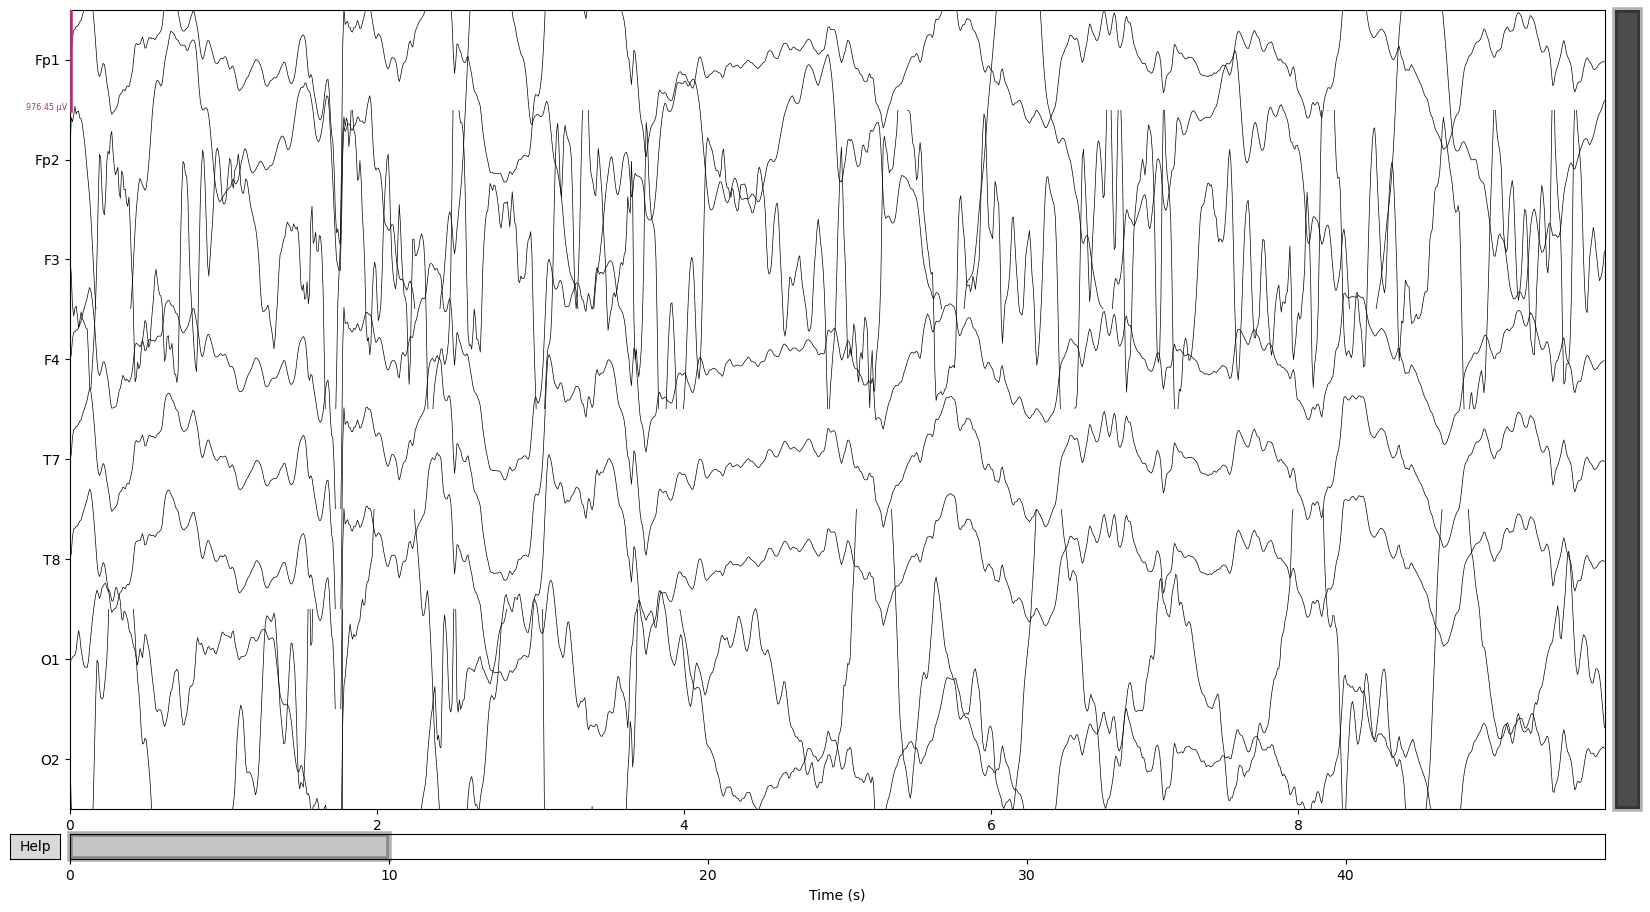

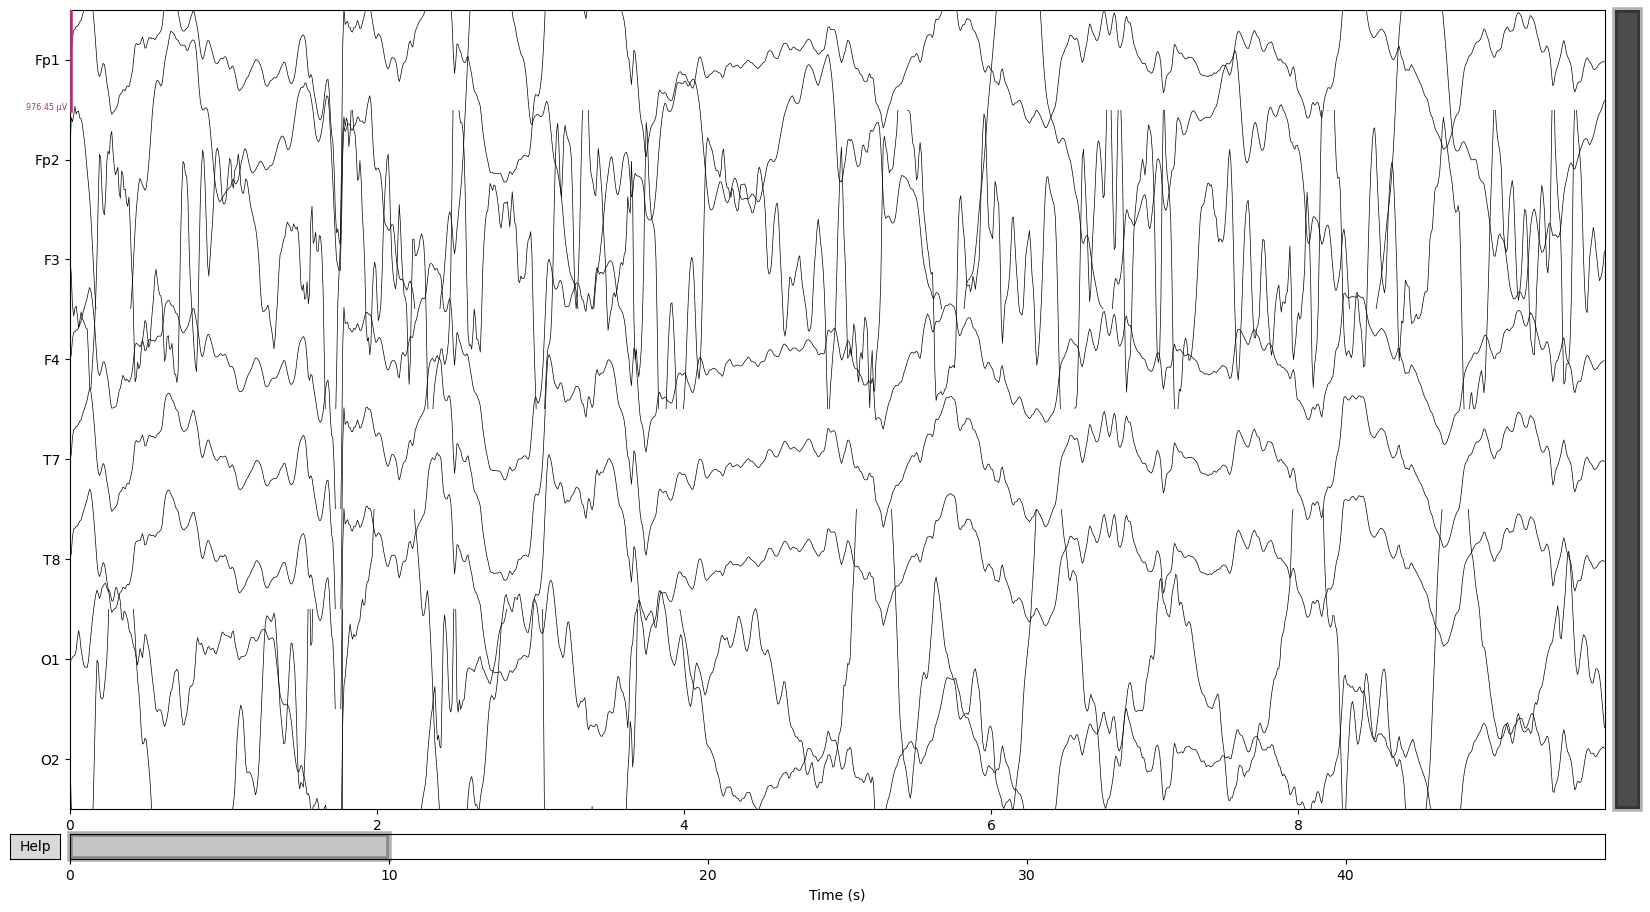

In [33]:
raw.plot(scalings='auto')
# raw.compute_psd().plot()

In [4]:
high_pass = raw.filter(l_freq=1, h_freq=None)
notch = high_pass.notch_filter(freqs=50)
band_pass = notch.filter(l_freq=1, h_freq=40)
reference = band_pass.set_eeg_reference()

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples

In [12]:
# b = np.zeros((len(data_rereference), len(data_rereference.T)+1))
# b[:,:-1] = data_rereference
# for i in index:
#     b[i:i+250,-1] = 1

In [76]:
type(reference)

mne.io.array._array.RawArray

In [26]:
# reference.plot(scalings=1e-2)

In [28]:
np.shape(data_raw)

(12034, 8)

In [50]:
markers[markers==1]

1

In [123]:
indexes = np.where(markers==1)[0]
index = []
for i in range(len(indexes)):
    if indexes[i] != indexes[i-1]+1:
        index.append(indexes[i])

In [124]:
len(index)

14

In [125]:
before = 100
after = 250

In [127]:
epoch_data = []

for i in index:
    data = reference.get_data()[:, i-before: i+after]
    epoch_data.append(data)

epoch_data = np.array(epoch_data)
np.shape(epoch_data)

(14, 8, 350)

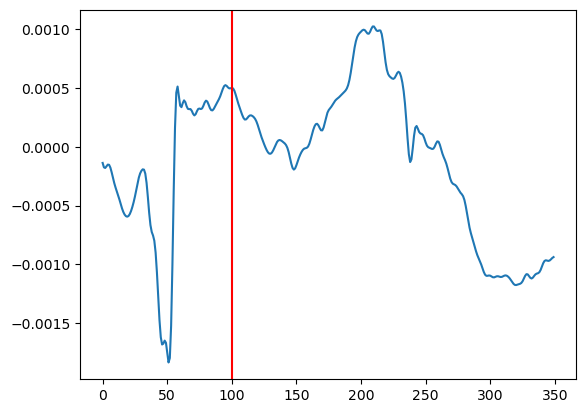

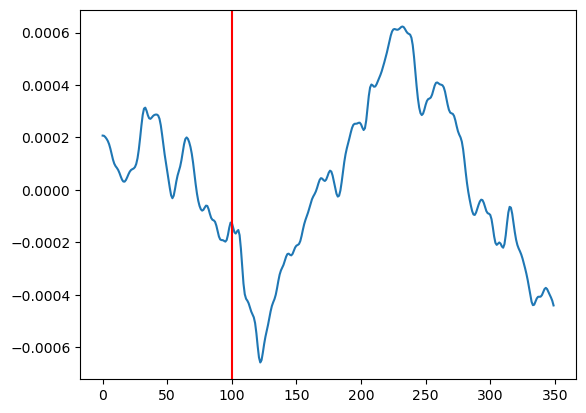

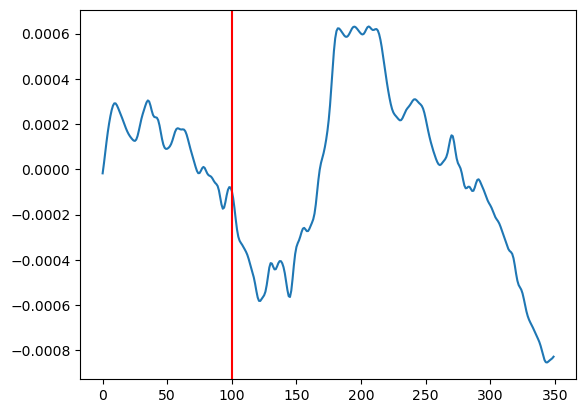

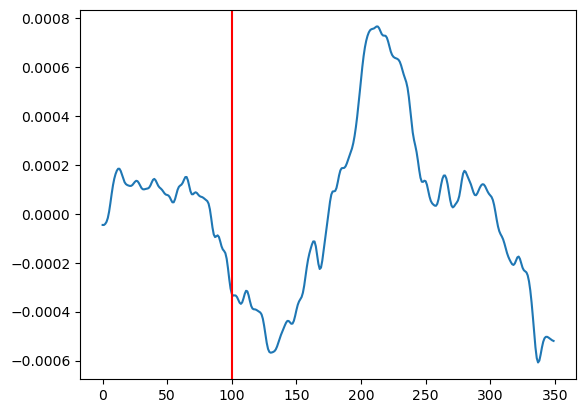

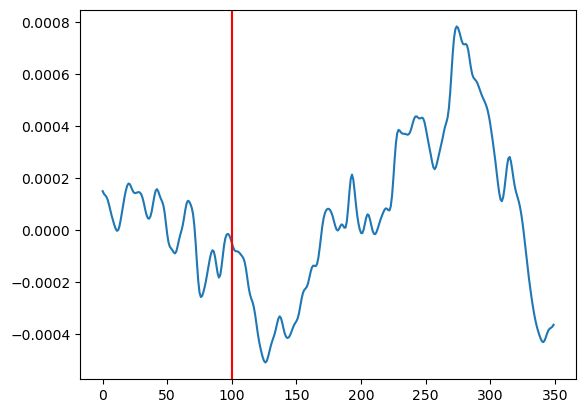

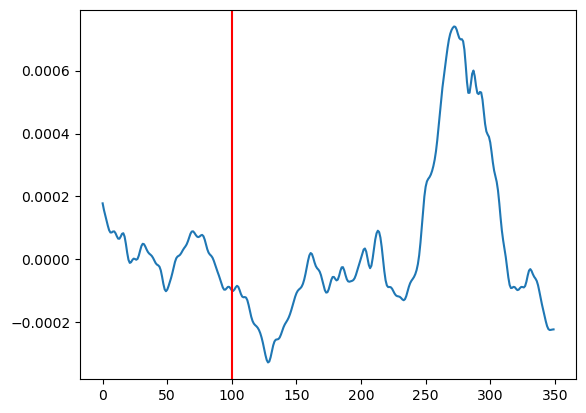

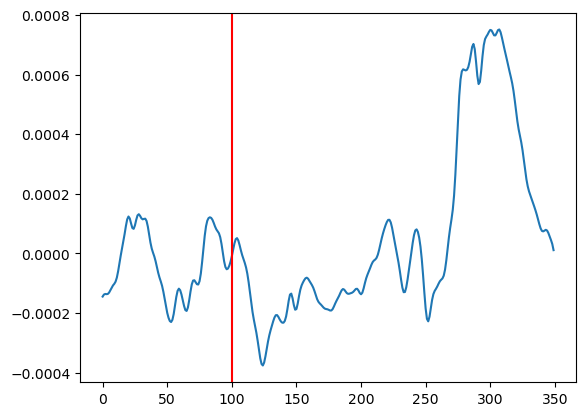

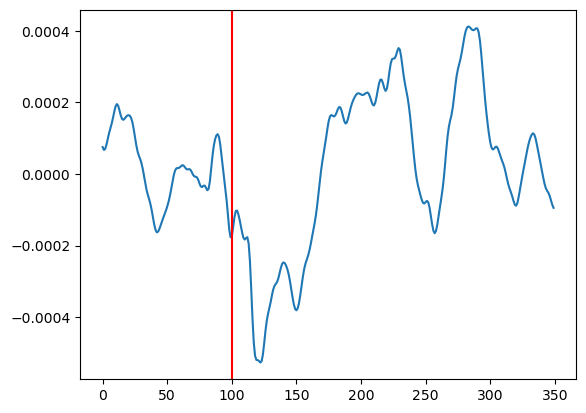

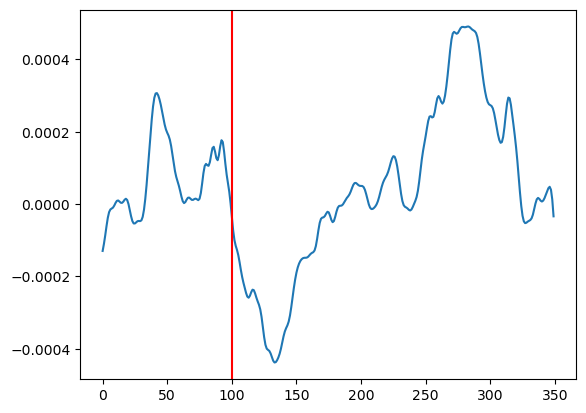

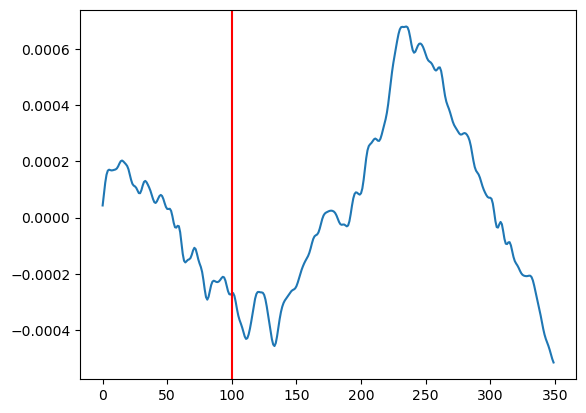

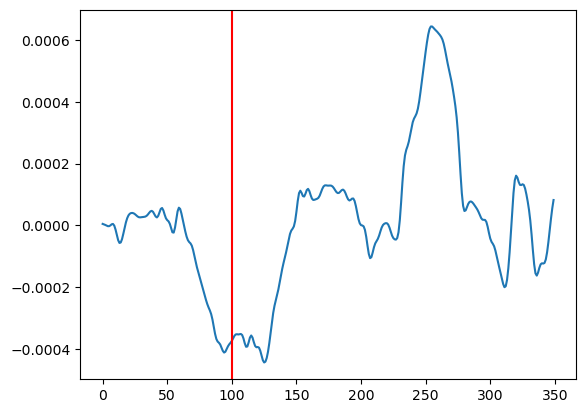

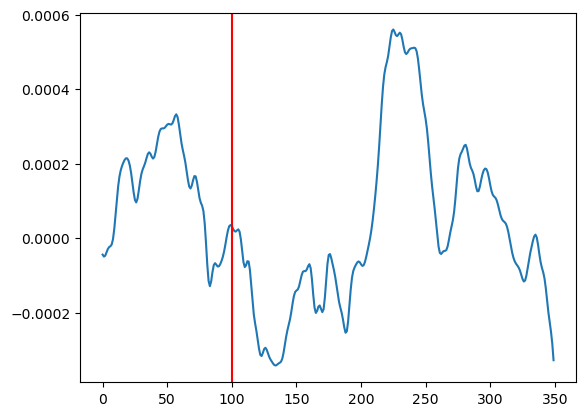

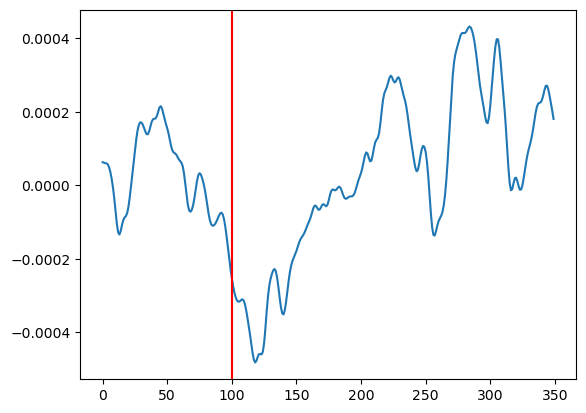

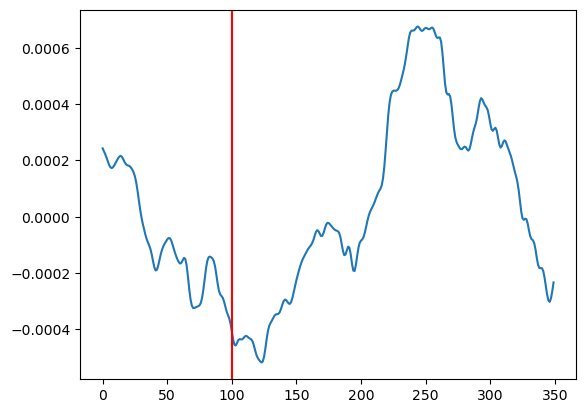

In [145]:
for i in epoch_data:
    plt.plot(i[4,:])
    plt.axvline(x=100, color='r')
    plt.show()
    


In [ ]:
features = {
        'mean': np.mean(data, axis=1),
        'std_dev': np.std(data, axis=1),
        'variance': np.var(data, axis=1),
        'skewness': skew(data, axis=1),
        'excess_kurtosis': kurtosis(data, axis=1)
        # 'mean_freq':,
        # 'max_psd':
    }

SyntaxError: expression expected after dictionary key and ':' (3254954345.py, line 7)